In [24]:
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np

from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea.analysis_tools import PackedSelection

import dask_awkward as dak

import itertools as iter

import hist
from hist import Hist

import vector as vec

In [2]:
class ScoutingNanoAODSchema(NanoAODSchema):

    mixins = {
        **NanoAODSchema.mixins,
        "ScoutingJet": "Jet" 
    }

In [17]:
file_list = [line.strip('\n') for line in open("TTto4Q_TuneCP5_13p6TeV_powheg-pythia8_0000.txt").readlines()] + [line.strip('\n') for line in open("TTto4Q_TuneCP5_13p6TeV_powheg-pythia8_0001.txt").readlines()]
file_list = ["root://cmseos.fnal.gov//" + string for string in file_list]

NanoAODSchema.warn_missing_crossrefs = False

events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "TTto4Q_TuneCP5_13p6TeV_powheg-pythia8"},
).events()

small_events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list[0:4]},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "TTto4Q_TuneCP5_13p6TeV_powheg-pythia8"},
).events()

#uproot.concatenate(file_list)

In [5]:
len(small_events.ScoutingJet.compute())

355872

In [26]:
vec.register_awkward()
trijet = ak.combinations(small_events.ScoutingJet[:,0:6], 3, fields=["j1", "j2", "j3"])

small_events["TriJet"] = ak.zip(
    {
        "px": trijet.j1.px + trijet.j2.px + trijet.j3.px, 
        "py": trijet.j1.py + trijet.j2.py + trijet.j3.py, 
        "pz": trijet.j1.pz + trijet.j2.pz + trijet.j3.pz,
        "e": trijet.j1.E + trijet.j2.E + trijet.j3.E
    },
    with_name="Momentum4D"
)

(array([0.00000e+00, 2.41000e+02, 5.37800e+03, 2.95160e+04, 9.28960e+04,
        2.05281e+05, 3.42623e+05, 4.58908e+05, 4.93380e+05, 4.68792e+05,
        4.30602e+05, 3.88496e+05, 3.45466e+05, 3.06449e+05, 2.68622e+05,
        2.35485e+05, 2.08333e+05, 1.83412e+05, 1.62163e+05, 1.44589e+05,
        1.29219e+05, 1.17339e+05, 1.05977e+05, 9.61430e+04, 8.73110e+04]),
 array([  0.,  20.,  40.,  60.,  80., 100., 120., 140., 160., 180., 200.,
        220., 240., 260., 280., 300., 320., 340., 360., 380., 400., 420.,
        440., 460., 480., 500.]),
 <BarContainer object of 25 artists>)

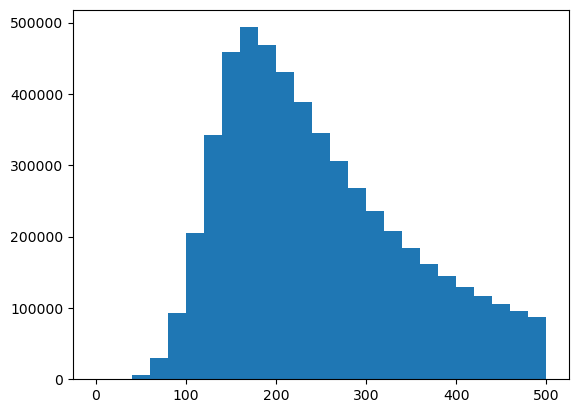

In [34]:
plt.hist(
    ak.flatten(small_events[ak.num(small_events.TriJet) == 20].TriJet.m).compute(),
    range=(0,500),
    bins=25
         )

AttributeError: module 'awkward' has no attribute 'permutaions'

In [51]:
ak.Array([1,2,3,4,5,6])

a,b,c,d,e,f = ak.unzip(ak.cartesian([arr,arr,arr,arr,arr,arr],axis=0))
cut = 

In [68]:
arr = ak.Array([1,2,3,4,5,6])

comb = ak.combinations(arr,3,axis=0)

ak.cartesian([comb,comb],axis=0)

<Array [((1, 2, ...), (...)), ..., (..., ...)] type='400 * ((int64, int64, ...'>